In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [45]:
df = pd.read_csv("data/stud (2).csv")

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [47]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [48]:
# checking columns names
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [49]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [50]:
# check for missing values
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [51]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [52]:
for col in df.columns:
    print("================================")
    print(f"Column: {col}")
    print(df[col].value_counts())

Column: gender
gender
female    518
male      482
Name: count, dtype: int64
Column: race_ethnicity
race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
Column: parental_level_of_education
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
Column: lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
Column: test_preparation_course
test_preparation_course
none         642
completed    358
Name: count, dtype: int64
Column: math_score
math_score
65    36
62    35
69    32
59    32
73    27
      ..
24     1
26     1
19     1
23     1
8      1
Name: count, Length: 81, dtype: int64
Column: reading_score
reading_score
72    34
74    33
64    32
73    30
67    30
      ..
17     1
26     1
28     1
23     1
40     1
Name: count, Length: 72, dtype: int

In [53]:
numeric_col=[feature for feature in df.columns if df[feature].dtype != 'str']
categorical_col=[feature for feature in df.columns if df[feature].dtype == 'str']

In [54]:
print( numeric_col)
print( categorical_col)

['math_score', 'reading_score', 'writing_score']
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


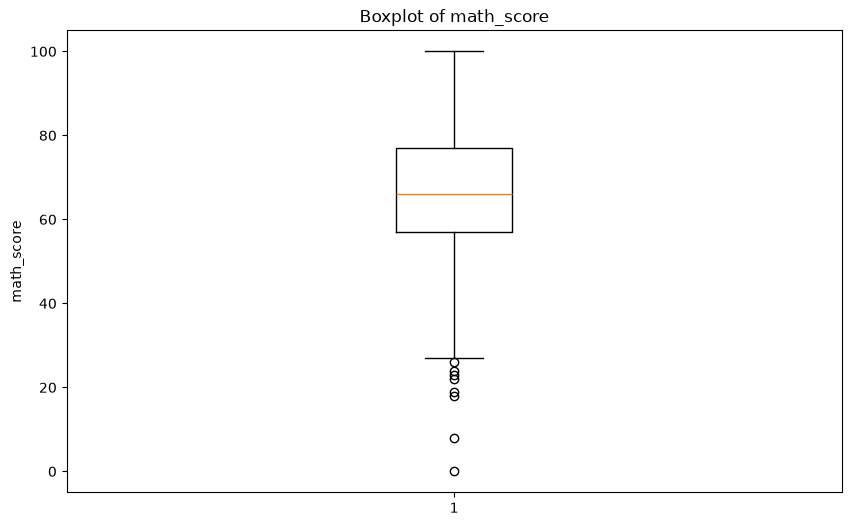

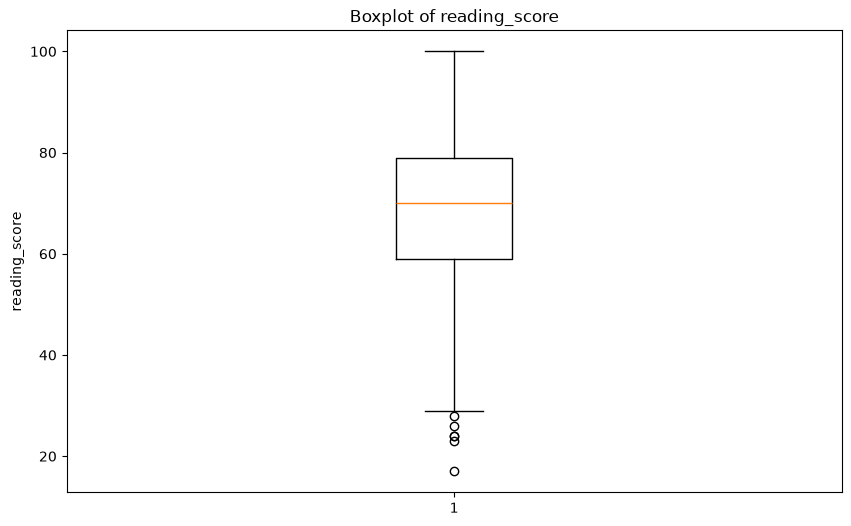

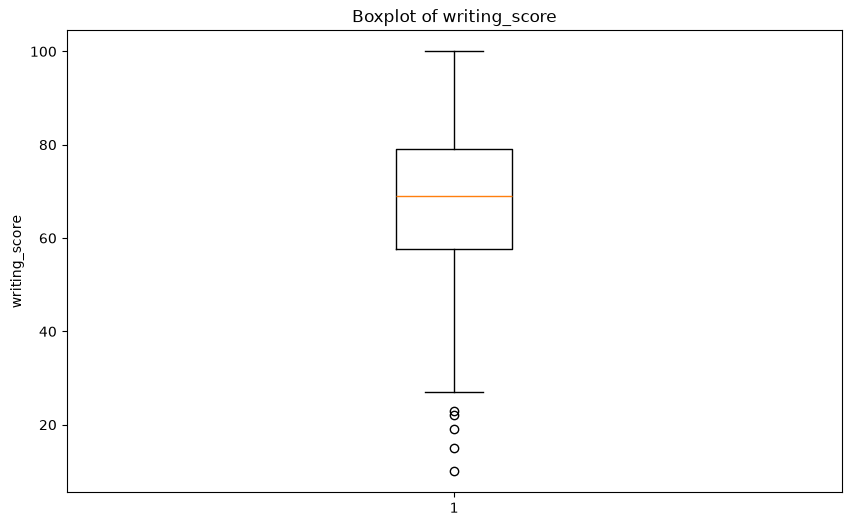

In [55]:
# check for outliers in numerical columns using boxplots

for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        plt.figure(figsize=(10, 6))
        plt.boxplot(df[col])
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)
        plt.show()

In [56]:
#  removing outliers from numerical columns using IQR method
# for col in df.columns:
#     if df[col].dtype in ['int64', 'float64']:
#         Q1 = df[col].quantile(0.25)
#         Q3 = df[col].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
#          df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [57]:
#student who score 100 in reading, math, and writing
reading_full=df[df['reading_score'] ==100]['lunch'].count()
math_full=df[df['math_score'] ==100]['lunch'].count()
writing_full=df[df['writing_score'] ==100]['lunch'].count()
print(f"Number of students who scored 100 in reading: {reading_full}")
print(f"Number of students who scored 100 in math: {math_full}")
print(f"Number of students who scored 100 in writing: {writing_full}")

Number of students who scored 100 in reading: 17
Number of students who scored 100 in math: 7
Number of students who scored 100 in writing: 14


In [58]:
#students who scored 20 or less in reading, math, and writing
reading_full=df[df['reading_score'] <=20 ]['lunch'].count()
math_full=df[df['math_score'] <=20 ]['lunch'].count()
writing_full=df[df['writing_score'] <=20 ]['lunch'].count()
print(f"Number of students who scored 20 or less in reading: {reading_full}")
print(f"Number of students who scored 20 or less in math: {math_full}")
print(f"Number of students who scored 20 or  in writing: {writing_full}")

Number of students who scored 20 or less in reading: 1
Number of students who scored 20 or less in math: 4
Number of students who scored 20 or  in writing: 3


In [59]:
df['Total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['Average_score'] = df['Total_score'] / 3

In [60]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [61]:
df.groupby('gender')['Average_score'].count()

gender
female    518
male      482
Name: Average_score, dtype: int64

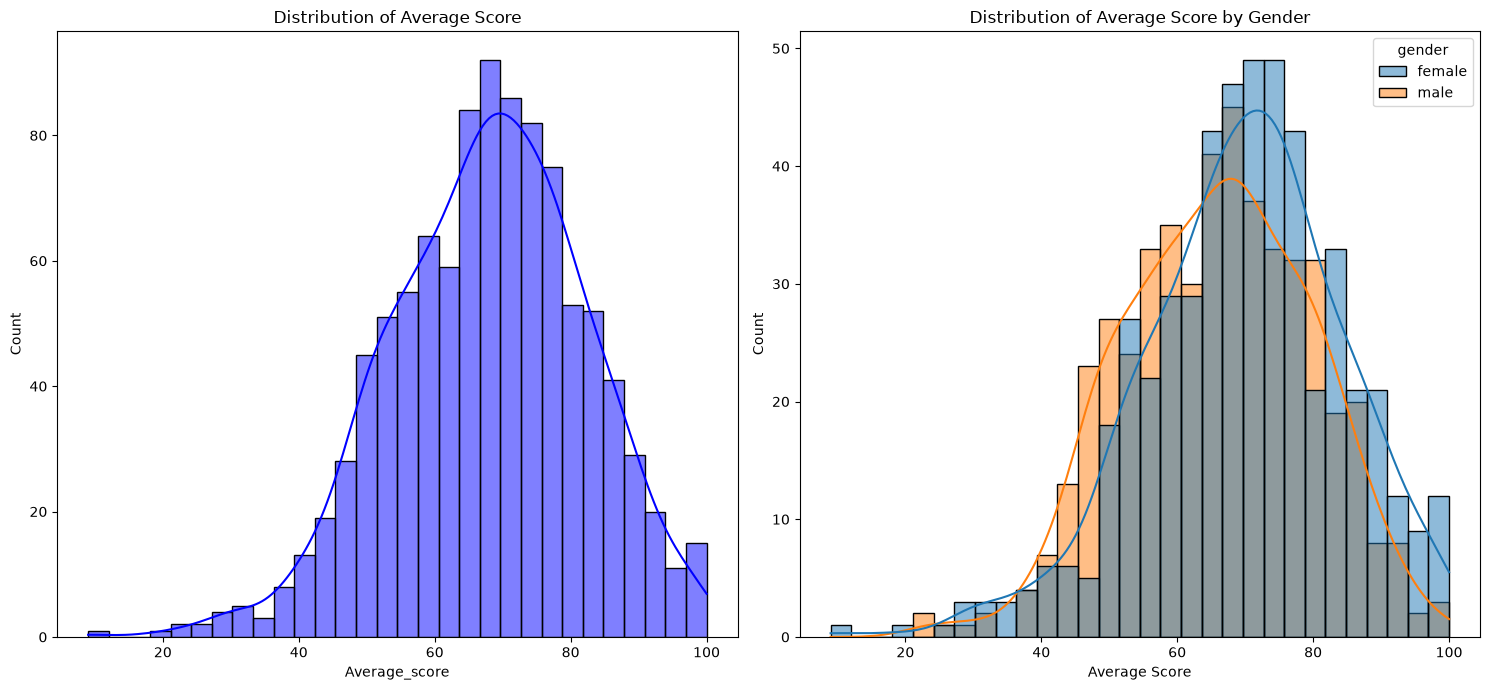

In [62]:
plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.histplot(df['Average_score'], kde=True, color='blue',bins=30)
plt.title('Distribution of Average Score')

plt.subplot(122)
sns.histplot(data=df, x='Average_score', hue='gender', kde=True, bins=30)
plt.title('Distribution of Average Score by Gender')
plt.xlabel('Average Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

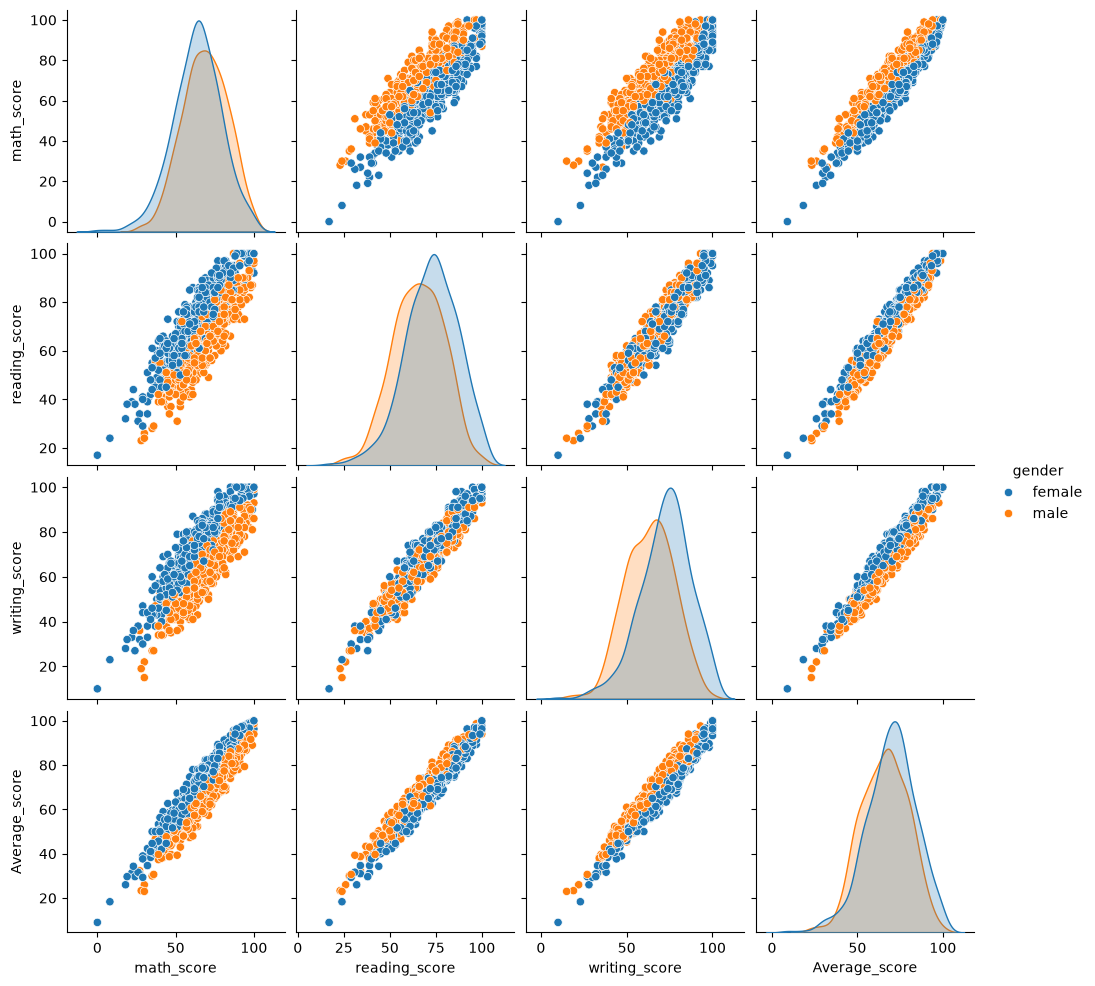

In [63]:
sns.pairplot(df, hue='gender', vars=['math_score', 'reading_score', 'writing_score', 'Average_score'])  

student count who got full mark in subject 


In [64]:
reading_full=df[df['reading_score'] == 100]['lunch'].count()
reading_full

np.int64(17)

In [65]:
#on the basis of lunch type avg score of women and men
avg_reading=df.groupby('lunch')['reading_score'].mean()
avg_math=df.groupby('lunch')['math_score'].mean()
avg_writing=df.groupby('lunch')['writing_score'].mean()
print("Average Scores by Lunch Type:")
print(avg_reading)
print(avg_math)
print(avg_writing)


Average Scores by Lunch Type:
lunch
free/reduced    64.653521
standard        71.654264
Name: reading_score, dtype: float64
lunch
free/reduced    58.921127
standard        70.034109
Name: math_score, dtype: float64
lunch
free/reduced    63.022535
standard        70.823256
Name: writing_score, dtype: float64


In [66]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


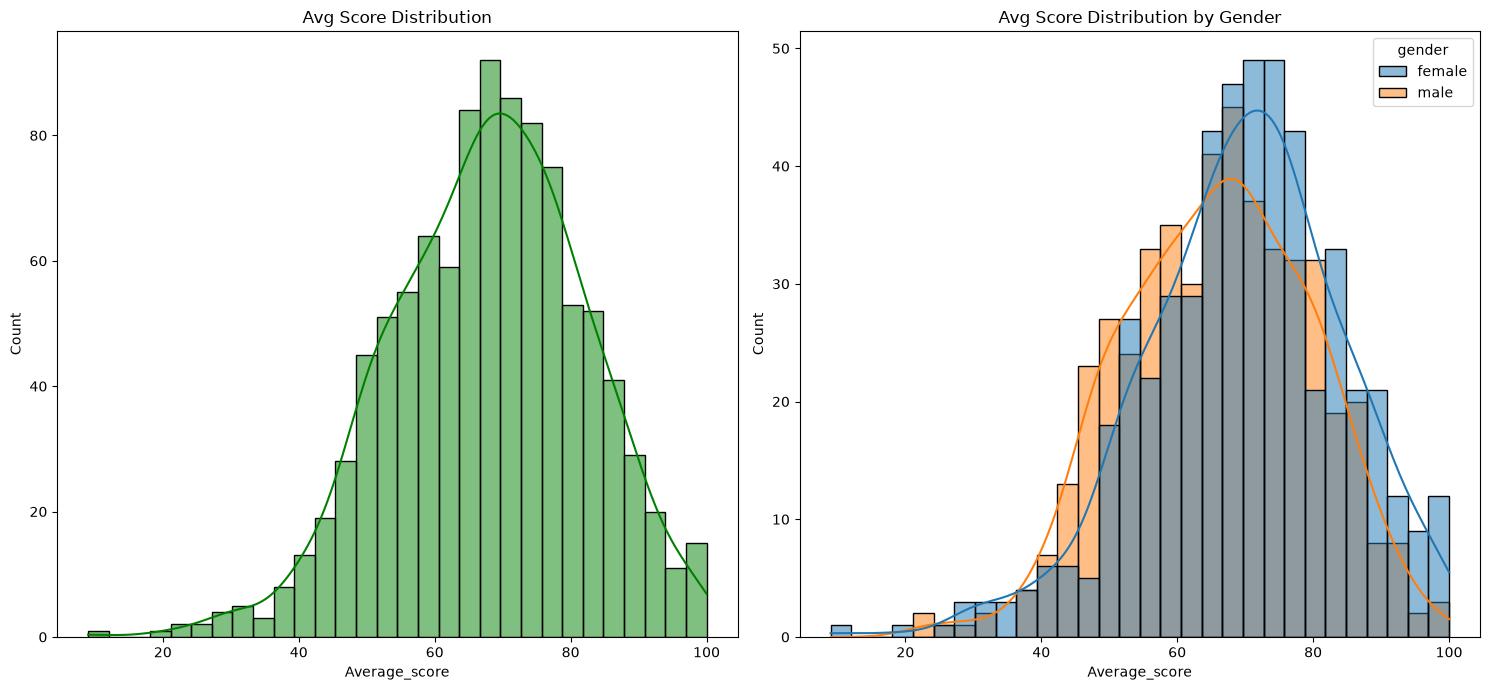

In [67]:
plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average_score',kde=True,bins=30,color='green')
plt.title('Avg Score Distribution')
plt.subplot(122)
sns.histplot(data=df,x='Average_score',kde=True,bins=30,color='green',hue='gender')
plt.title('Avg Score Distribution by Gender')
plt.tight_layout()
plt.show()

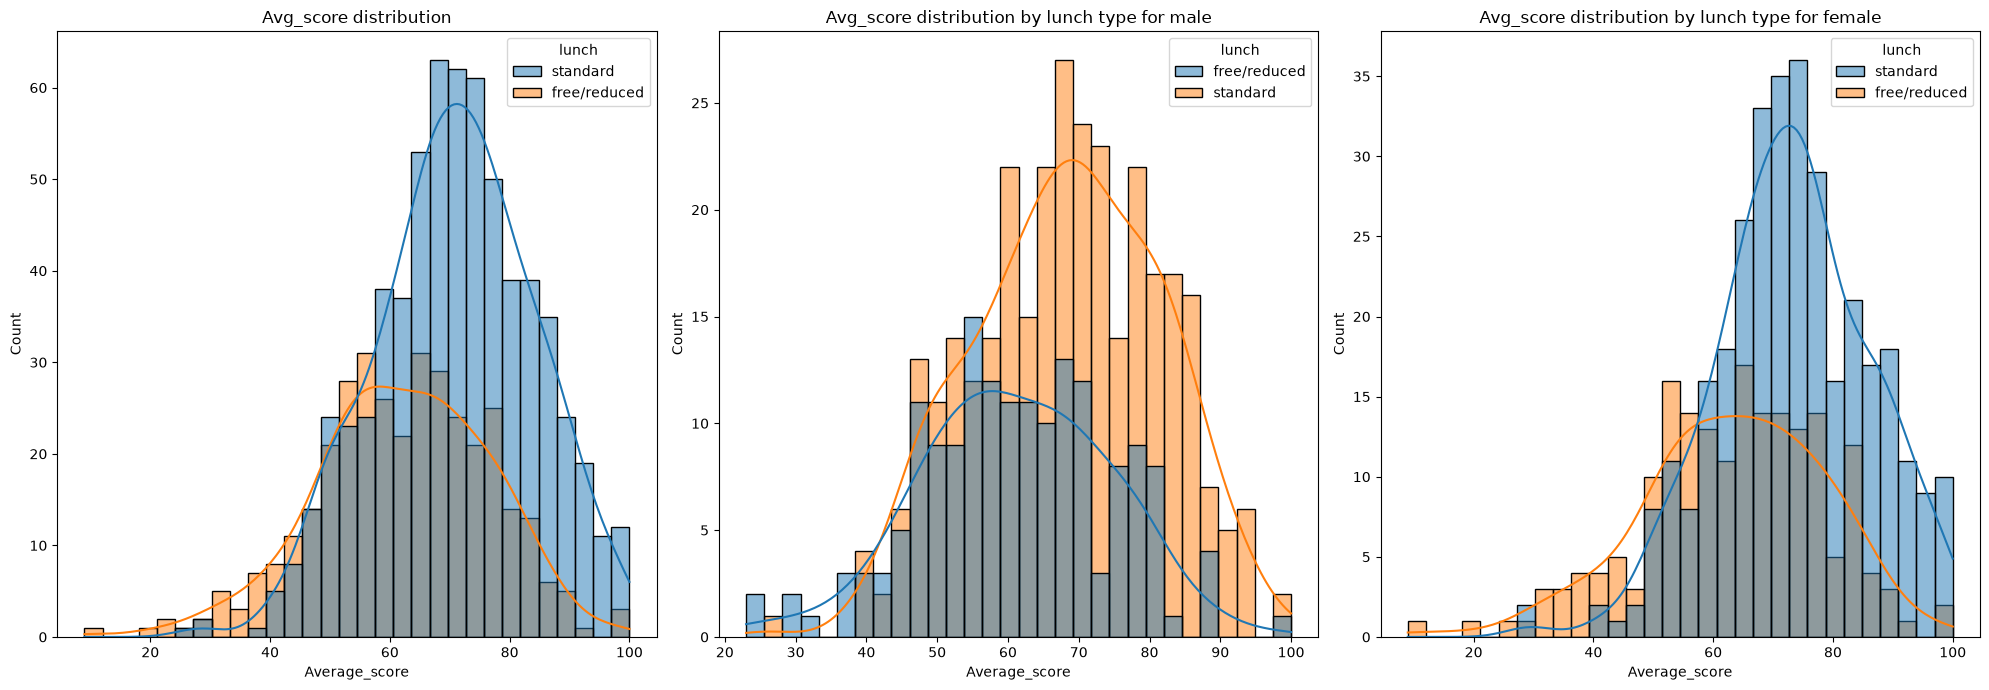

In [68]:
plt.subplots(1, 3, figsize=(20, 7))
plt.subplot(131)
sns.histplot(data=df,x='Average_score',kde=True,bins=30,color='green',hue='lunch')
plt.title('Avg_score distribution')

plt.subplot(132)
sns.histplot(data=df[df.gender=='male'],x='Average_score',kde=True,bins=30,color='yellow',hue='lunch')
plt.title('Avg_score distribution by lunch type for male')

plt.subplot(133)
sns.histplot(data=df[df.gender=='female'],x='Average_score',kde=True,bins=30,color='blue',hue='lunch')
plt.title('Avg_score distribution by lunch type for female')
plt.tight_layout()
plt.show()

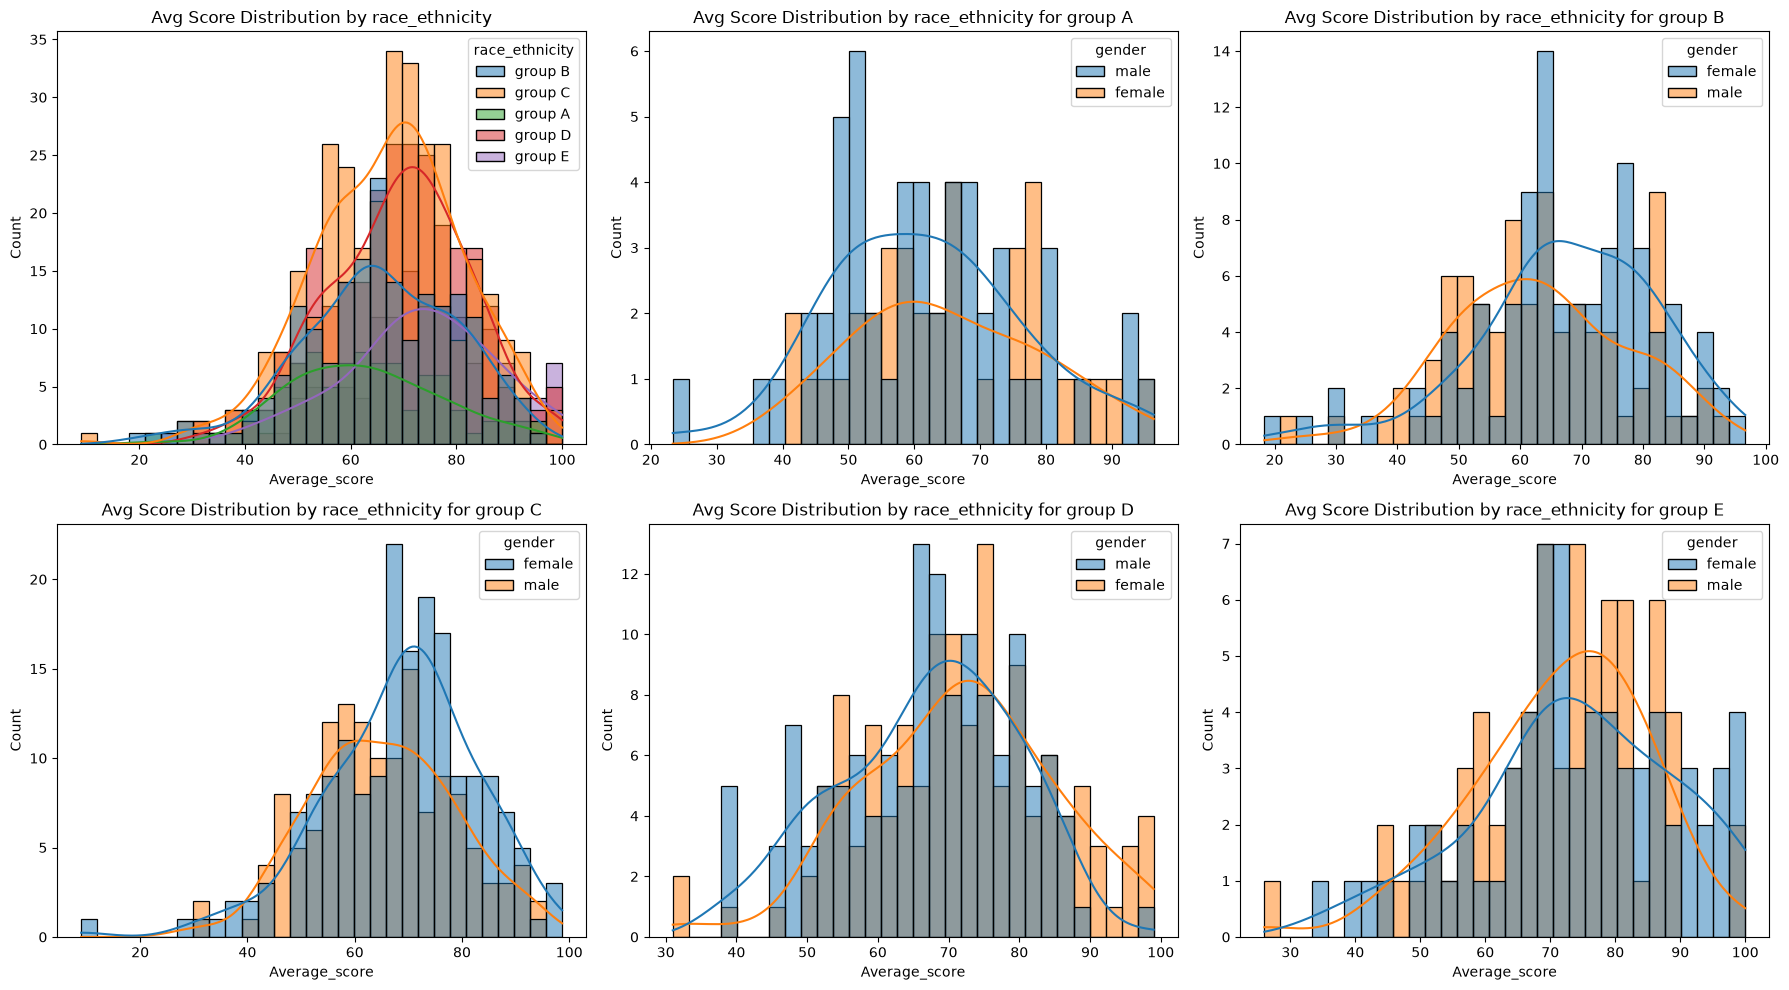

In [69]:
plt.subplots(2,3,figsize=(18,10))

plt.subplot(231)
sns.histplot(data=df,x='Average_score',kde=True,bins=30,color='green',hue='race_ethnicity')
plt.title("Avg Score Distribution by race_ethnicity")

plt.subplot(232)
sns.histplot(data=df[df['race_ethnicity']=='group A'],x='Average_score',kde=True,bins=30,color='green',hue='gender')
plt.title("Avg Score Distribution by race_ethnicity for group A")

plt.subplot(233)
sns.histplot(data=df[df['race_ethnicity']=='group B'],x='Average_score',kde=True,bins=30,color='green',hue='gender')
plt.title("Avg Score Distribution by race_ethnicity for group B")   

plt.subplot(234)
sns.histplot(data=df[df['race_ethnicity']=='group C'],x='Average_score',kde=True,bins=30,color='green',hue='gender')
plt.title("Avg Score Distribution by race_ethnicity for group C")

plt.subplot(235)
sns.histplot(data=df[df['race_ethnicity']=='group D'],x='Average_score',kde=True,bins=30,color='green',hue='gender')
plt.title("Avg Score Distribution by race_ethnicity for group D")

plt.subplot(236)
sns.histplot(data=df[df['race_ethnicity']=='group E'],x='Average_score',kde=True,bins=30,color='green',hue='gender')
plt.title("Avg Score Distribution by race_ethnicity for group E")

plt.tight_layout()
plt.show()

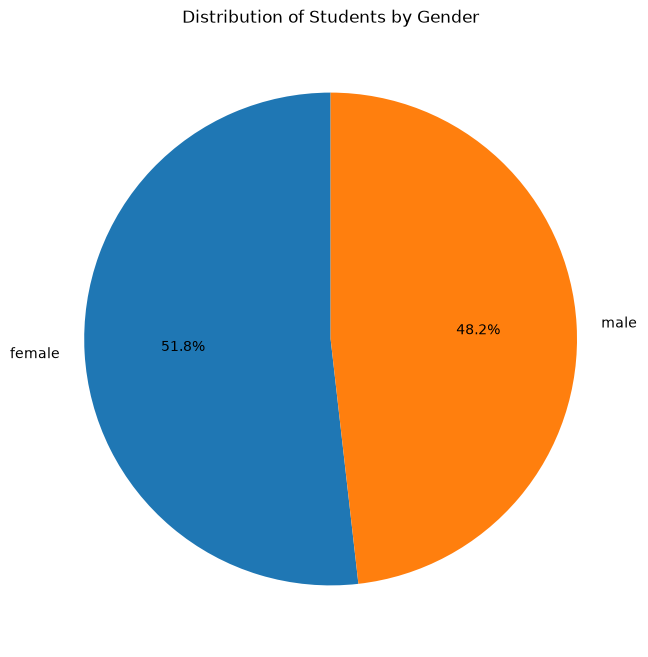

In [70]:
#student distribution by gender 
gender_count=df['gender'].value_counts()
#create a pie chart to visiualize the distribution of students by gender
plt.figure(figsize=(8, 8))
plt.pie(gender_count.values, labels=gender_count.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Students by Gender')
plt.show() 

In [71]:
#find race_ethnicity by gender 
race_ethnicity_by_gender = df.groupby('gender')['race_ethnicity'].value_counts().unstack(fill_value=0)
race_ethnicity_by_gender

race_ethnicity,group A,group B,group C,group D,group E
gender,,,,,
female,36,104,180,129,69
male,53,86,139,133,71


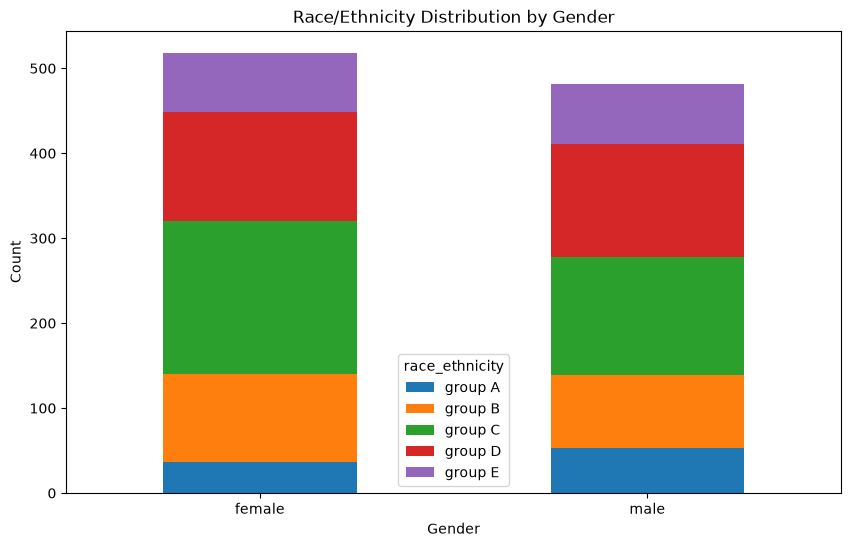

In [72]:
#find race_ethnicity by gender
race_ethnicity_gender = df.groupby('gender')['race_ethnicity'].value_counts().unstack(fill_value=0)
race_ethnicity_gender.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Race/Ethnicity Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)  
plt.show()

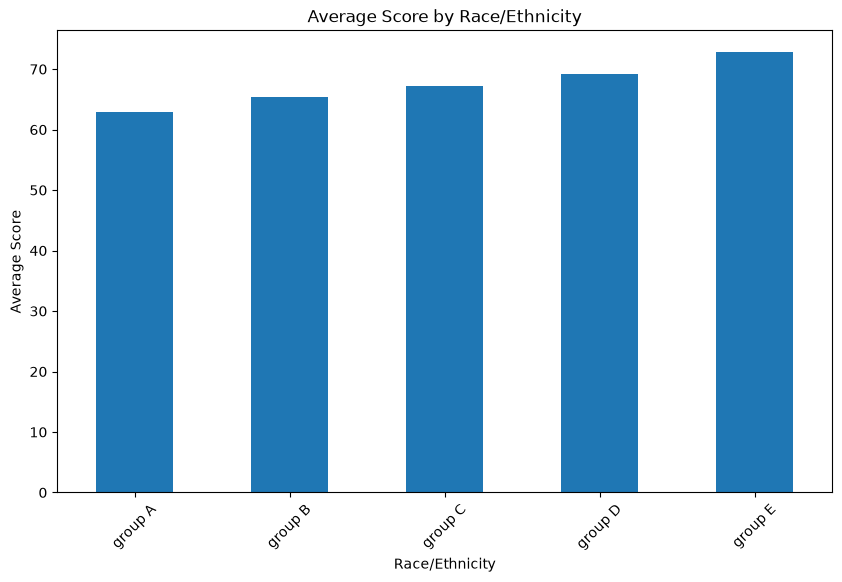

In [73]:
#find relation between race_ethnicity and average score
avg_score_by_race = df.groupby('race_ethnicity')['Average_score'].mean()
avg_score_by_race.plot(kind='bar', figsize=(10, 6))
plt.title('Average Score by Race/Ethnicity')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.show()

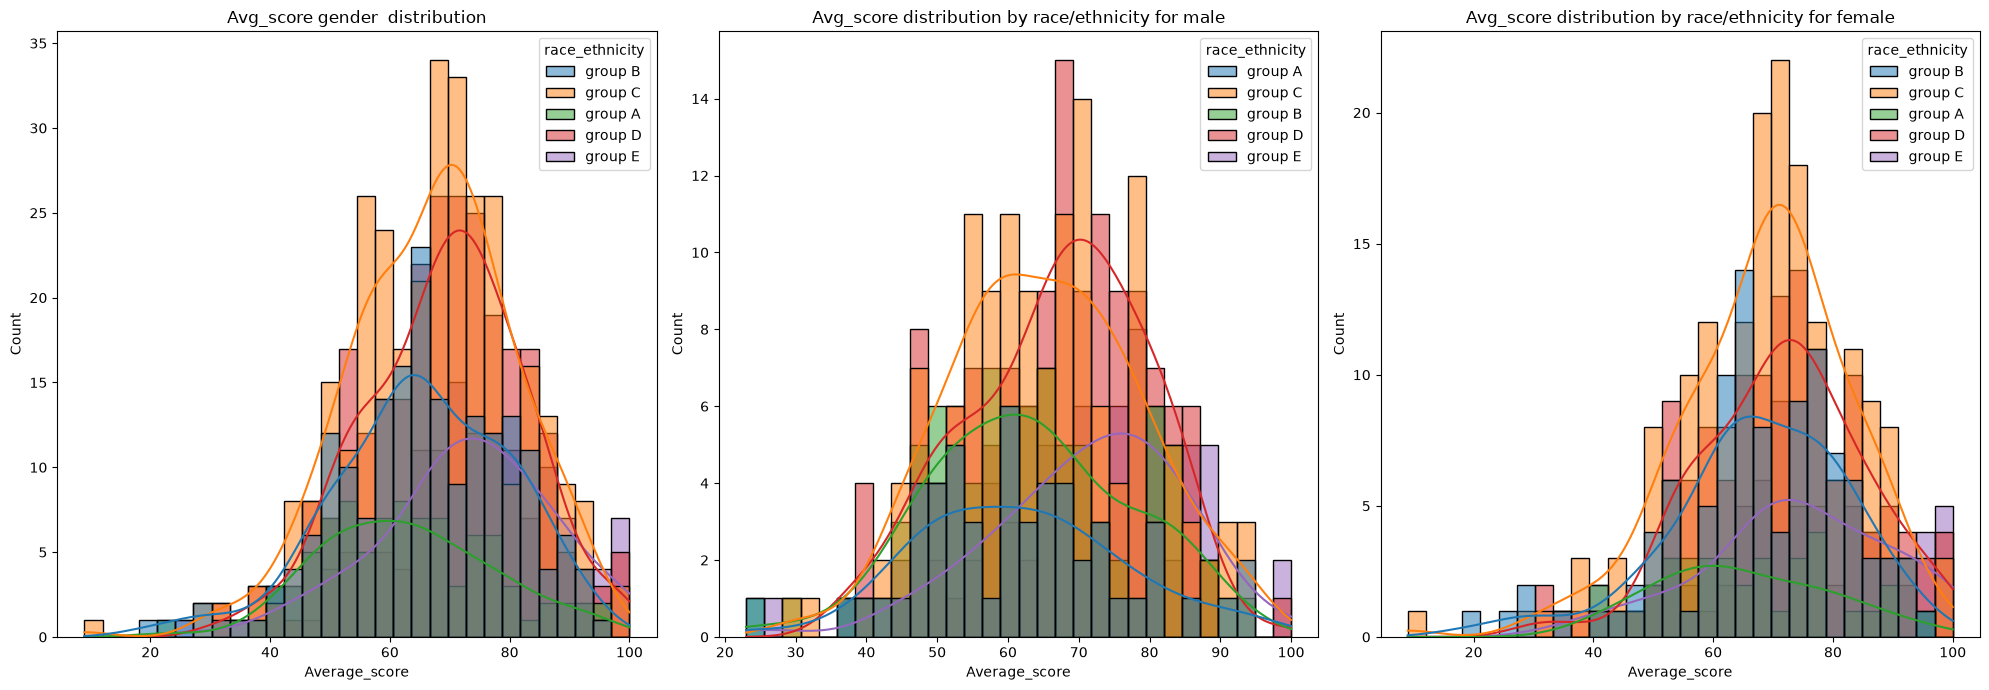

In [74]:
plt.subplots(1, 3, figsize=(20, 7))
plt.subplot(131)
sns.histplot(data=df,x='Average_score',kde=True,bins=30,color='green',hue='race_ethnicity')
plt.title('Avg_score gender  distribution')

plt.subplot(132)
sns.histplot(data=df[df.gender=='male'],x='Average_score',kde=True,bins=30,color='yellow',hue='race_ethnicity')
plt.title('Avg_score distribution by race/ethnicity for male')

plt.subplot(133)
sns.histplot(data=df[df.gender=='female'],x='Average_score',kde=True,bins=30,color='blue',hue='race_ethnicity')
plt.title('Avg_score distribution by race/ethnicity for female')
plt.tight_layout()
plt.show()

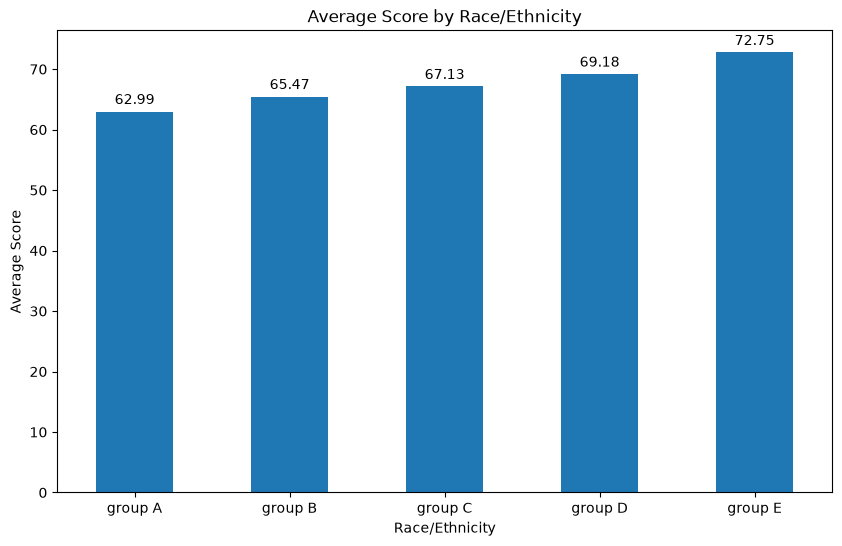

In [75]:
#find relationship between race_ethnicity and average score
avg_score_by_race = df.groupby('race_ethnicity')['Average_score'].mean()
ax= avg_score_by_race.plot(kind='bar', figsize=(10,6))
#show values on top of bars
ax.bar_label(ax.containers[0],fmt='%.2f',padding=3)
plt.title('Average Score by Race/Ethnicity')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Average Score') 
plt.xticks(rotation=0)
plt.show()
    

In [76]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000
998,female,group D,some college,standard,completed,68,78,77,223,74.333333


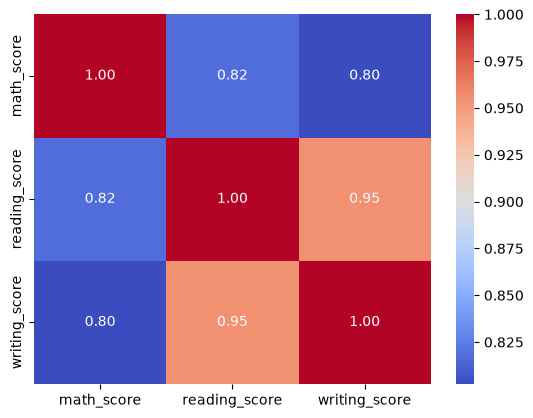

In [93]:
corr =df[score_cols].corr() 
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

Student who perform well in reading tend to perform well in writting 


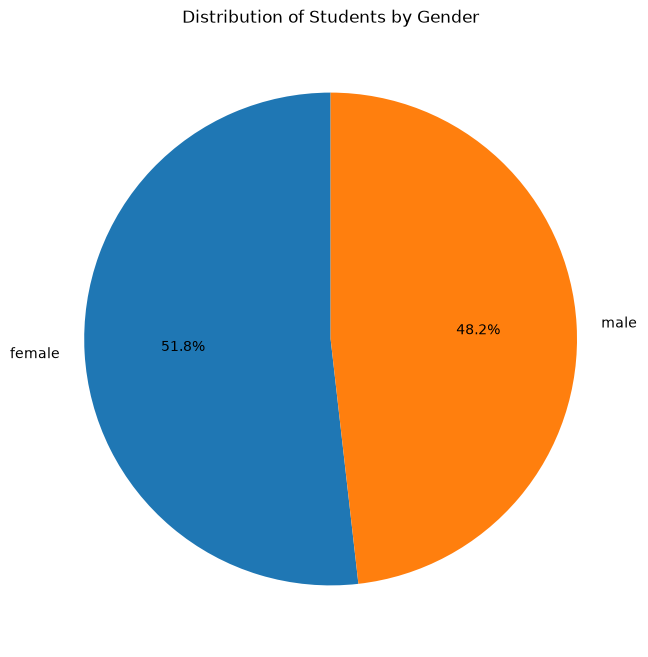

In [ ]:
#student distribution by gender 
gender_count=df['gender'].value_counts()
#create a pie chart to visiualize the distribution of students by gender
plt.figure(figsize=(8, 8))
plt.pie(gender_count.values, labels=gender_count.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Students by Gender')
plt.show() 

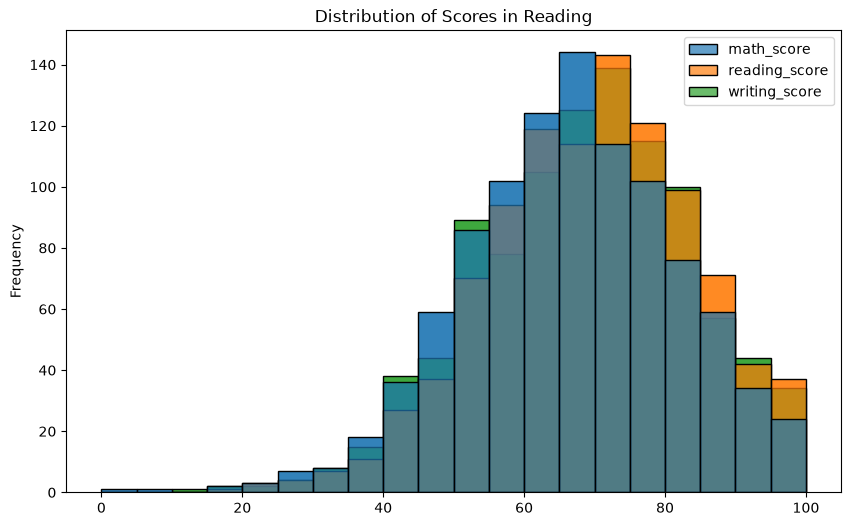

In [92]:
df[score_cols].plot(kind='hist',bins=20, figsize=(10, 6), alpha=0.7)
sns.histplot(df[score_cols], bins=20, alpha=0.7)
plt.title('Distribution of Scores in Reading')
plt.show()

In [ ]:
#=====================================
#pass analysis 
#=====================================
#Assuming 40 is passing in each subject
df['passed_all'] = ((df['math_score'] >= 40) & (df['reading_score'] >= 40) & (df['writing_score'] >= 40))
print('student passing all subjects:', df['passed_all'].sum())
print(' pass percentage', df['passed_all'].mean() * 100)

student passing all subjects: 949
 pass percentage 94.89999999999999


lunch         test_preparation_course
free/reduced  completed                  68.0
              none                       59.0
standard      completed                  76.0
              none                       68.0
Name: Average_score, dtype: float64


<Axes: xlabel='lunch,test_preparation_course'>

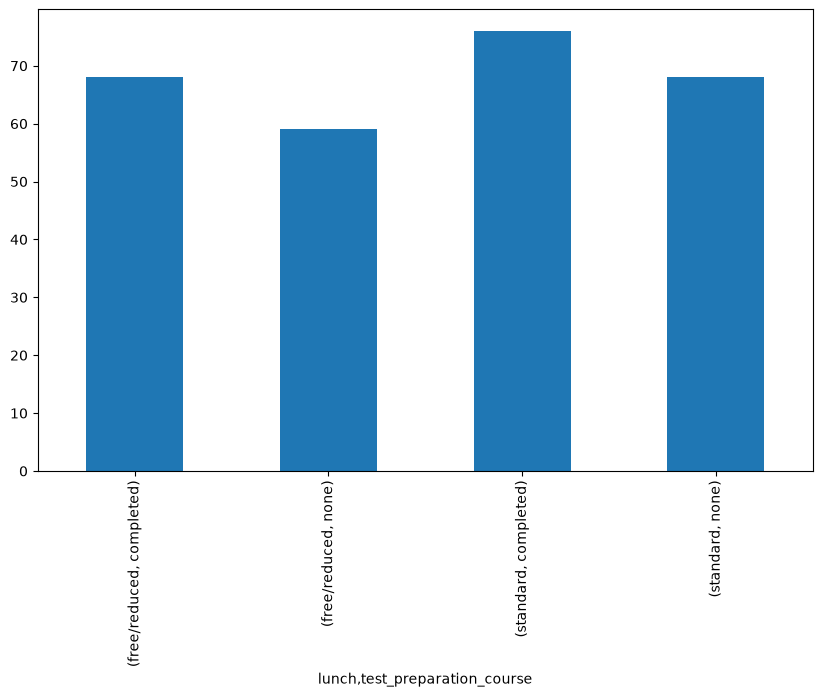

In [ ]:
#==================
#lunch+prepration 
#==================
result=(df.groupby(['lunch', 'test_preparation_course'])['Average_score'].mean().round())
print(result)
result.plot(kind='bar', figsize=(10, 6))

In [79]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


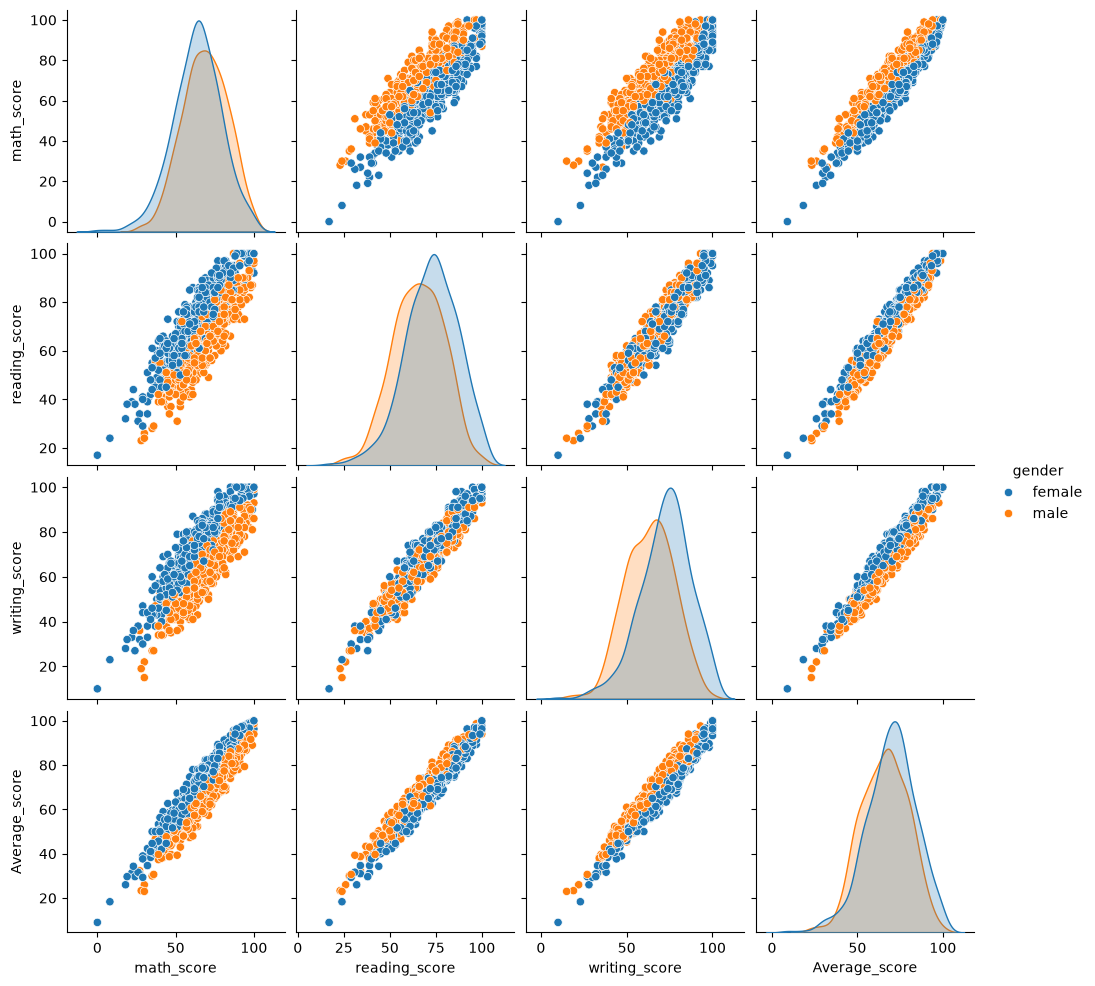

In [94]:
sns.pairplot(df, hue='gender', vars=['math_score', 'reading_score', 'writing_score', 'Average_score'])